### Development notebook for PPO

In [1]:
from utils import * 
from sparse_mc import SparseMountainCar
config['ENV_NAME'] = "SparseMountainCar-v0"

class Transition(NamedTuple):
    done: jnp.ndarray
    action: jnp.ndarray
    value: jnp.ndarray
    i_value: jnp.ndarray # extra - intrinsic value from second value head
    reward: jnp.ndarray
    intrinsic_reward: jnp.ndarray # extra - intrinsic reward (RND loss)
    log_prob: jnp.ndarray
    obs: jnp.ndarray
    embedding: jnp.ndarray # extra - target embedding from target rnd network
    info: jnp.ndarray

def make_train(config):
    def initialize_rnd_network(rng, obs_shape):
        rnd_network = RND_Net(activation=config["ACTIVATION"])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        rnd_params = rnd_network.init(_rng, init_x)
        return rnd_network, rnd_params
    
    def initialize_network(n_actions, obs_shape, rng):
        network = Two_Head_ActorCritic(n_actions, activation=config["ACTIVATION"])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        network_params = network.init(_rng, init_x)
        return network, network_params 
    
    batch_size = config["NUM_STEPS"] * config["NUM_ENVS"]
    config["NUM_MINIBATCHES"] = batch_size // config["MINIBATCH_SIZE"] # per epoch
    config["NUM_UPDATES"] = config["TOTAL_TIMESTEPS"] // batch_size
    total_grad_steps = config["NUM_UPDATES"] * config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"]
    
    env = SparseMountainCar()
    env_params = env.default_params
    env = FlattenObservationWrapper(env)  
    env = LogWrapper(env)      # Log REAL returns (possibly sparse)

    if config["NORMALIZE_REWARDS"]:
        env = NormalizeRewardWrapper(env, gamma=config["GAMMA"]) # Normalize Rewards
    if config["NORMALIZE_OBS"]:
        env = NormalizeObservationWrapper(env) # Normalize Obs
    
    n_actions = env.action_space(env_params).n

    def train(rng):
        # initialize rnd networks
        rnd_rng, rng = jax.random.split(rng)
        target_rng, rng = jax.random.split(rng)
        rnd_net, rnd_params = initialize_rnd_network(rnd_rng, env.observation_space(env_params).shape)
        _, target_params = initialize_rnd_network(target_rng, env.observation_space(env_params).shape)
        
        # initialize value and policy network
        network_rn, rng = jax.random.split(rng)
        network, network_params = initialize_network(n_actions, env.observation_space(env_params).shape, rng)

        lr_scheduler = optax.linear_schedule(
            init_value=config["LR"],
            end_value=config["LR_END"],
            transition_steps=total_grad_steps
        )
        tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adamw(lr_scheduler, eps=1e-5),
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )
        rnd_state = RNDTrainState.create(
            apply_fn=rnd_net.apply,
            params=rnd_params,
            tx=tx,
            target_params=target_params,
        )
        get_features_fn = lambda params, obs: train_state.apply_fn(params, obs, method="get_value_features", )[0]
        batch_get_features = jax.vmap(get_features_fn, in_axes=(None, 0))

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # WARMUP:
        def _warmup_step(runner_state, unused):
            env_state, last_obs, rng = runner_state
            
            # Select RANDOM actions (no need for network here, just exploring state space)
            rng, _rng = jax.random.split(rng)
            rng_action = jax.random.split(_rng, config["NUM_ENVS"])
            action = jax.vmap(env.action_space(env_params).sample)(rng_action)
            
            # Step env (wrappers will update their internal mean/std stats automatically)
            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, config["NUM_ENVS"])
            obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                rng_step, env_state, action, env_params
            )
            
            return (env_state, obsv, rng), None

        # Run the warmup
        warmup_runner_state = (env_state, obsv, rng)
        (env_state, obsv, rng), _ = jax.lax.scan(
            _warmup_step, warmup_runner_state, None, config["WARMUP"]
        )
        # -------------------------

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            # COLLECT TRAJECTORIES
            def _env_step(env_scan_state, unused):
                train_state, rnd_state, env_state, last_obs, rng= env_scan_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value, i_value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                target_embedding = rnd_state.apply_fn(rnd_state.target_params, obsv) # should be N_ENVS x N_STEPS x k
                pred = rnd_state.apply_fn(rnd_state.params, obsv)
                cosine_sim = jax.vmap(cosine_similarity, in_axes = (0,0))(pred, target_embedding) # range from -1 to 1
                
                intrinsic_reward =  0.5 * (1.0 - cosine_sim) # should range from 0 to 1. most similar = 0, least similar = 1

                transition = Transition(
                    done, action, value, i_value, reward, intrinsic_reward, log_prob, last_obs, target_embedding, info
                )
                runner_state = (train_state, rnd_state, env_state, obsv, rng)
                return runner_state, transition
            
            train_state, rnd_state, env_state, last_obs, rng, idx = runner_state
            env_step_state = (train_state, rnd_state, env_state, last_obs, rng)
            (_, _, env_state, last_obs, rng), traj_batch = jax.lax.scan(
                _env_step, env_step_state , None, config["NUM_STEPS"]
            )
            
            # CALCULATE ADVANTAGE
            _, last_val, last_i_val = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, i_gae, next_value, i_next_value = gae_and_next_value
                    done, value, reward, i, i_value = (
                        transition.done,
                        transition.value,
                        transition.reward,
                        transition.intrinsic_reward,
                        transition.i_value,
                    )
                    
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = delta + (config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae)
                    
                    i_delta = i + config["GAMMA"] * i_next_value - i_value # no episodic termination for intrinsic reward.
                    i_gae = i_delta + (config["GAMMA"] * config["GAE_LAMBDA"] * i_gae)
                    
                    return (gae, i_gae, value, i_value), (gae, i_gae)

                _, (advantages, i_advantages) = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), jnp.zeros_like(last_val), last_val, last_i_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return (advantages, i_advantages), (advantages + traj_batch.value, i_advantages + traj_batch.i_value)

            gaes, targets = _calculate_gae(traj_batch, last_val) # now both tuples of (gae, i_gae)
            advantages = gaes[0] + gaes[1] # combine extrinsic and intrinsic advantages for training policy

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                
                def _update_minbatch(minibatch_input, batch_info):
                    train_state, rnd_state, mask_rng = minibatch_input
                    traj_batch, advantages, targets = batch_info
                    
                    def rnd_loss_fn(rnd_params, target_embeddings, mask):
                        # RERUN NETWORK
                        pred = rnd_net.apply(rnd_params, traj_batch.obs)
                        cosine_sim = jax.vmap(cosine_similarity, in_axes = (0,0))(pred, target_embeddings)
                        losses = -cosine_sim
                        loss = (losses * mask).sum() / (mask.sum() + 1e-8)
                        return loss, _

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value, i_val = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)
                        targets, i_targets = targets
                        
                        # *Extrinsic* VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["VF_CLIP"], config["VF_CLIP"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )
                        
                        # *Intrinsic* VALUE LOSS
                        value_pred_clipped = traj_batch.i_value + (
                            i_val - traj_batch.i_value
                        ).clip(-config["VF_CLIP"], config["VF_CLIP"])
                        value_losses = jnp.square(i_val - i_targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - i_targets)
                        i_value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )

                        # CALCULATE ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2)
                        loss_actor = loss_actor.mean()
                        entropy = pi.entropy().mean()

                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            + config["VF_COEF"] * i_value_loss
                            - config["ENT_COEF"] * entropy
                        )
                        return total_loss, (i_value_loss, value_loss, loss_actor, entropy)
                    # end loss_fn

                    # --- UPDATE PPO ---
                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    # FIX 2: Correct unpacking. grad_fn returns ((loss, aux), grads)
                    (total_loss, _), grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    
                    # --- UPDATE RND ---
                    rnd_grad_fn = jax.value_and_grad(rnd_loss_fn, has_aux=True)
                    # mask fraction of the data
                    mask = jax.random.bernoulli(mask_rng, p=config['RND_TRAIN_FRAC'], shape=(traj_batch.obs.shape[0],))
                    (rnd_loss, _), rnd_grads = rnd_grad_fn(rnd_state.params, traj_batch.embedding, mask)
                    rnd_state = rnd_state.apply_gradients(grads=rnd_grads)
                    return (train_state, rnd_state, mask_rng), (total_loss, rnd_loss)
                # end update_minibatch

                train_state, rnd_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                rng, mask_rng = jax.random.split(rng)
                (train_state, rnd_state, mask_rng), total_loss = jax.lax.scan(
                    _update_minbatch, (train_state, rnd_state, mask_rng), minibatches
                )
                update_state = (train_state, rnd_state, traj_batch, advantages, targets, rng)
                return update_state, total_loss

            features = batch_get_features(train_state.params, traj_batch.obs)
            feat_norm = jnp.linalg.norm(features, axis=-1).mean()

            update_state = (train_state, rnd_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["NUM_EPOCHS"]
            )
            train_state, rnd_state, _, _, _, rng = update_state
            metric = {k: v.mean() for k, v in traj_batch.info.items()} # performance

            metric.update({
                "ppo_loss": loss_info[0].mean(), 
                "rnd_loss": loss_info[1].mean(),
                "feat_norm": feat_norm,
                "gae_mean": gaes[0].mean(),
                "gae_std": gaes[0].std(),
                "gae_max": gaes[0].max(),
                "intrinsic_gae_mean": gaes[1].mean(),
                "intrinsic_gae_std": gaes[1].std(),
                "intrinsic_gae_max": gaes[1].max(),
                # "td_error_mean":td_error_mean,
                # "td_error_std": td_error_std,
                "intrinsic_rew_mean": traj_batch.intrinsic_reward.mean(),
                "intrinsic_rew_std": traj_batch.intrinsic_reward.std(),
                "intrinsic_val_mean": traj_batch.i_value.mean(),
                "intrinsic_val_std": traj_batch.i_value.std(),
            })
            runner_state = (train_state, rnd_state, env_state, last_obs, rng, idx+1)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, rnd_state, env_state, obsv, _rng, 0)
        runner_state, metrics = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metrics}

    return train

/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


time: 55.56 s


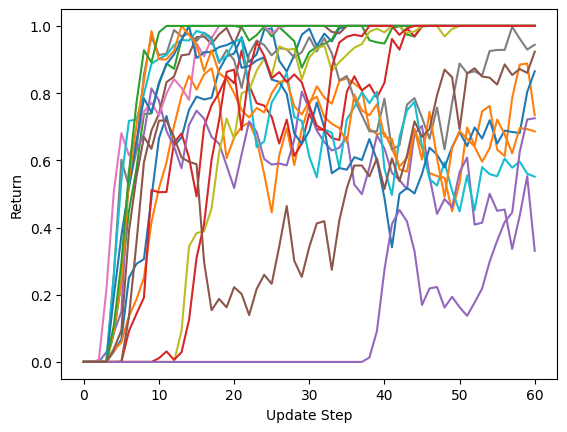

Global Mean: 0.772373616695404
Global SEM:  0.009257565252482891


In [ ]:
import time
import matplotlib.pyplot as plt
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, config['N_SEEDS'])
train_vjit = jax.jit(jax.vmap(make_train(config)))
t0 = time.time()
outs = jax.block_until_ready(train_vjit(rngs))
print(f"time: {time.time() - t0:.2f} s")

for i in range(config['N_SEEDS']):
    plt.plot(outs["metrics"]["returned_episode_returns"][i])
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title('RND (cosine similarity)')
plt.show()

returns = outs["metrics"]["returned_episode_returns"][:, 10:]

# 1. Global Standard Error (Matching your .mean() calculation)
# Uses all 244 points (4 seeds * 61 updates) as samples
sem_global = returns.std() / np.sqrt(returns.size)

print(f"Global Mean: {returns.mean()}")
print(f"Global SEM:  {sem_global}")

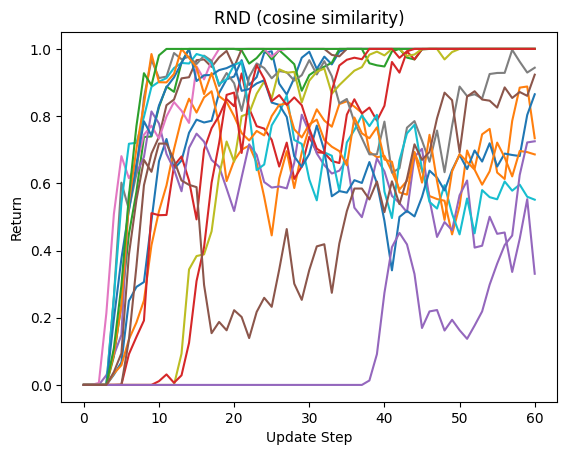

Global Mean: 0.772373616695404
Global SEM:  0.009257565252482891


In [6]:
for i in range(config['N_SEEDS']):
    plt.plot(outs["metrics"]["returned_episode_returns"][i])
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title('RND (cosine similarity)')
plt.show()

returns = outs["metrics"]["returned_episode_returns"][:, 10:]

# 1. Global Standard Error (Matching your .mean() calculation)
# Uses all 244 points (4 seeds * 61 updates) as samples
sem_global = returns.std() / np.sqrt(returns.size)

print(f"Global Mean: {returns.mean()}")
print(f"Global SEM:  {sem_global}")

In [3]:
returns = outs["metrics"]["returned_episode_returns"][:, 10:]

# 1. Global Standard Error (Matching your .mean() calculation)
# Uses all 244 points (4 seeds * 61 updates) as samples
sem_global = returns.std() / np.sqrt(returns.size)

print(f"Global Mean: {returns.mean()}")
print(f"Global SEM:  {sem_global}")


Global Mean: 0.772373616695404
Global SEM:  0.009257565252482891


In [4]:
# Calculate Standard Error
sem_curve = returns.std(axis=0) / np.sqrt(returns.shape[0])

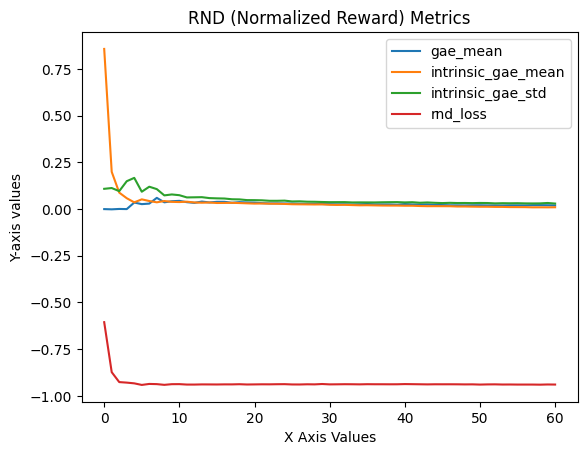

In [5]:
# plt.plot(outs["metrics"]["feat_norm"].mean(0), label = 'feature norm')
plt.plot(outs["metrics"]["gae_mean"].mean(0), label = 'gae_mean')
plt.plot(outs["metrics"]["intrinsic_gae_mean"].mean(0), label = 'intrinsic_gae_mean')
plt.plot(outs["metrics"]["intrinsic_gae_std"].mean(0), label = 'intrinsic_gae_std')
plt.plot(outs["metrics"]["rnd_loss"].mean(0), label = 'rnd_loss')

plt.legend()
# Add labels and a title for clarity
plt.xlabel('X Axis Values')
plt.ylabel('Y-axis values')
plt.title('RND (Normalized Reward) Metrics')

# Display the plot
plt.savefig('RND Metrics (Normalized Reward).pdf', bbox_inches='tight')
plt.show()